
⏱ Temps d'entraînement du modèle SVM : 0.43 secondes

=== SVM ===
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       227
           1       0.87      0.92      0.90       426

    accuracy                           0.86       653
   macro avg       0.85      0.83      0.84       653
weighted avg       0.86      0.86      0.86       653

Accuracy: 0.8591117917304747


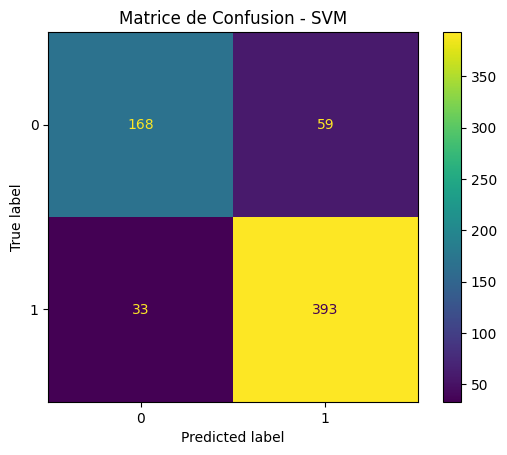

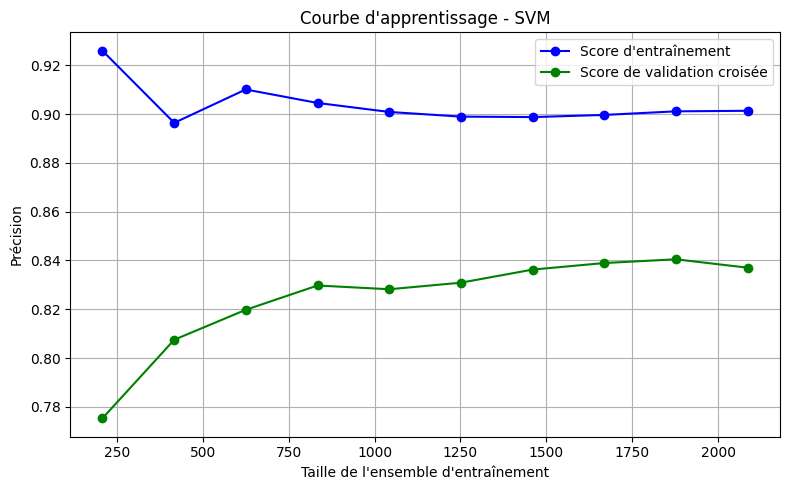

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time  
df = pd.read_csv("missions_fusionnees.csv")
X = df.drop(columns=["is_attack"])  
y = df["is_attack"]

X = X.fillna(X.mean(numeric_only=True)) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf', C=1.0)

start_time = time.time()
svm.fit(X_train_scaled, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"\n⏱ Temps d'entraînement du modèle SVM : {training_time:.2f} secondes")

y_pred = svm.predict(X_test_scaled)
print("\n=== SVM ===")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Matrice de Confusion - SVM")
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    svm, X_train_scaled, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Score d'entraînement")
plt.plot(train_sizes, test_scores_mean, 'o-', color="green", label="Score de validation croisée")
plt.title("Courbe d'apprentissage - SVM")
plt.xlabel("Taille de l'ensemble d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.show()


In [2]:
import joblib
joblib.dump(svm, 'svm_7.pkl')


['svm_7.pkl']